## BTSP on a linear track

* Linear track, single direction
* CA3: 8 preset place fields
* CA1: 
  * Hebbian learning + BTSP learning at targeted neurons
  * BTSP learning: long-tailed (pre) Hebbian learning with a high output firing rate considered (occurs in one trajectory only)
  * (1) 1 cell, receives BTSP signal at a reward location
  * (2) 4 cells, with 2 receiving BTSP signals (near reward and start, respectively) 

Evaluate resulting CA1 neuron place field properties

In [1]:
import copy
from pathlib import Path
import sys
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox

add_paths = [str(Path(".."))]
for add_path in add_paths:
    if add_path not in sys.path:
        sys.path.append(add_path)

from predhpc import agent, neurons, run_manager, plot_util, util

In [2]:
ratinabox.stylize_plots()
ratinabox.autosave_plots = False
ratinabox.figure_directory = "figures"

In [3]:
warnings.filterwarnings(
    "ignore", message="solid 1D boundary", category=UserWarning
)
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

## Define some functions

In [4]:
def learn(env_params, agent_params, CA3_PC_params, CA1_params, 
          num_rewards=200, max_num_steps=5000, use_Hebbian=False, 
          target_reach_num_for_btsp=5):
    
    print_vals = {
        "Agent dt": agent_params["dt"],
        "# CA3 PCs": CA3_PC_params["n"], 
        "# CA1s": CA1_params["n"], 
        "CA1 init at 0": CA1_params["init_weights_zero"], 
        "CA1 init scale": CA1_params["w_init_scale"], 
        "CA1 BTSP tau": CA1_params["btsp_tau"], 
        "# rewards": num_rewards, 
        "Max # steps": max_num_steps, 
        "Hebbian learning": use_Hebbian, 
        "target # for BTSP": target_reach_num_for_btsp,
    }
    print_vals = [
        f"{name:16}: {value}" for name, value in print_vals.items()
    ]
    print("{}\n".format('\n'.join(print_vals)))
    
    Env, Ag, CA3_PCs, CA1s = run_manager.learn_1D_btsp(
        env_params,
        agent_params,
        CA3_PC_params,
        CA1_params,
        num_rewards=num_rewards,
        max_num_steps=max_num_steps,
        use_Hebbian=use_Hebbian,
        target_reach_num_for_btsp=target_reach_num_for_btsp
    )
    
    return Env, Ag, CA3_PCs, CA1s

## Reload

In [5]:
import importlib
importlib.reload(agent)
importlib.reload(neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(util);

## Only 1 CA1 neuron

In [6]:
NUM_REWARDS = 8
MAX_NUM_STEPS = 5000
USE_HEBBIAN = False

CA1_params = {
    "n": 1,
    "init_weights_zero": True,
    "w_init_scale": 0.1, # set fairly small
    "btsp_tau": run_manager.AGENT_PARAMS["dt"] * 5,
    "btsp_fr": 30,
    "lr": 5e-5,
    "apply_Ojas_rule": True,
}

CA1_params_one = copy.deepcopy(run_manager.CA1_PARAMS)
CA1_params_one.update(CA1_params)

Agent dt        : 0.02
# CA3 PCs       : 16
# CA1s          : 1
CA1 init at 0   : True
CA1 init scale  : 0.1
CA1 BTSP tau    : 0.1
# rewards       : 8
Max # steps     : 5000
Hebbian learning: False
target # for BTSP: 4



 12%|████▌                                  | 578/5000 [00:01<00:08, 495.74it/s]


Trajectory lengths (9) to date: 1.29 +/- 0.56 sec each
Trajectory lengths (9) to date: 64.33 +/- 28.00 steps each


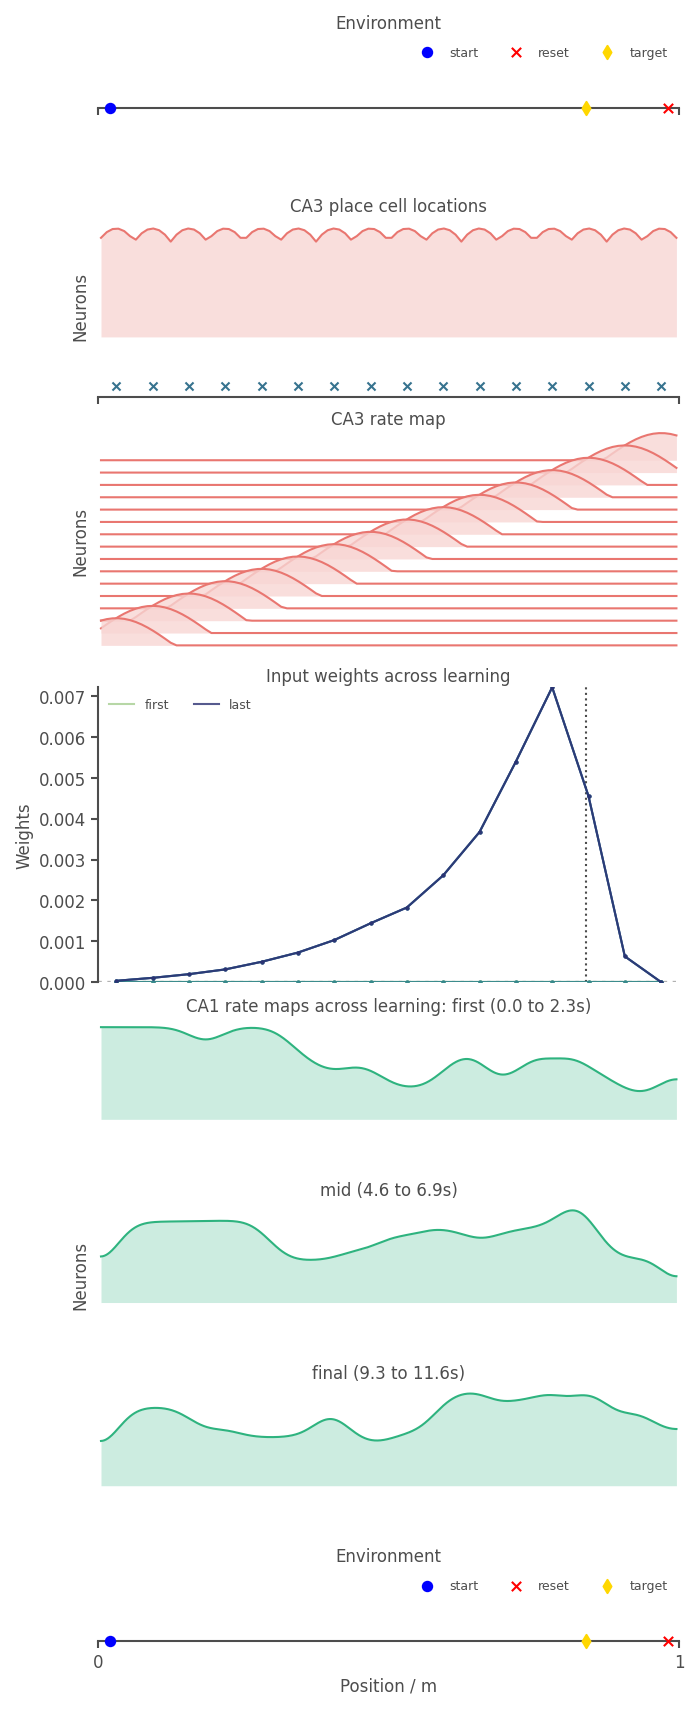

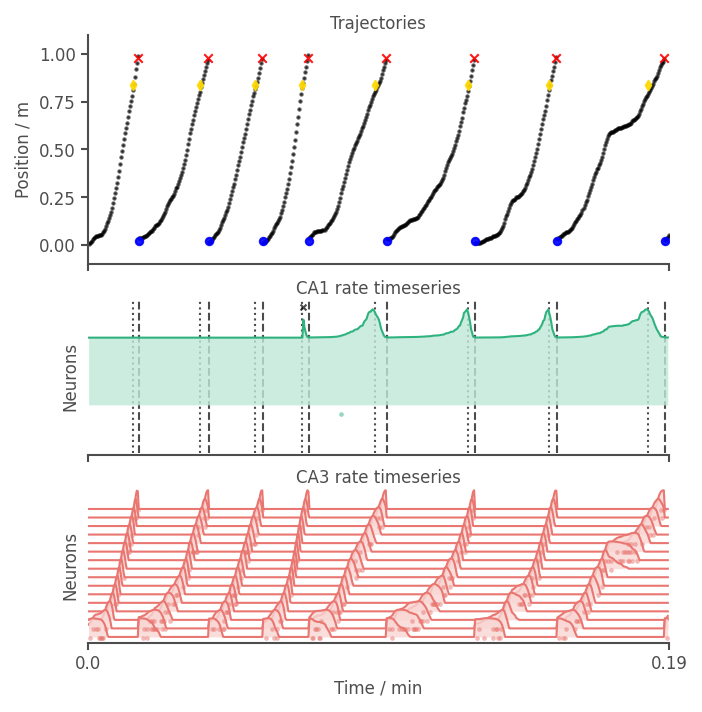

In [7]:
Env, Ag, CA3_PCs, CA1s = learn(
    run_manager.ENV_PARAMS, 
    run_manager.AGENT_PARAMS, 
    run_manager.CA3_PC_PARAMS, 
    CA1_params_one, 
    num_rewards=NUM_REWARDS, 
    max_num_steps=MAX_NUM_STEPS,
    use_Hebbian=USE_HEBBIAN,
    target_reach_num_for_btsp=4,
)

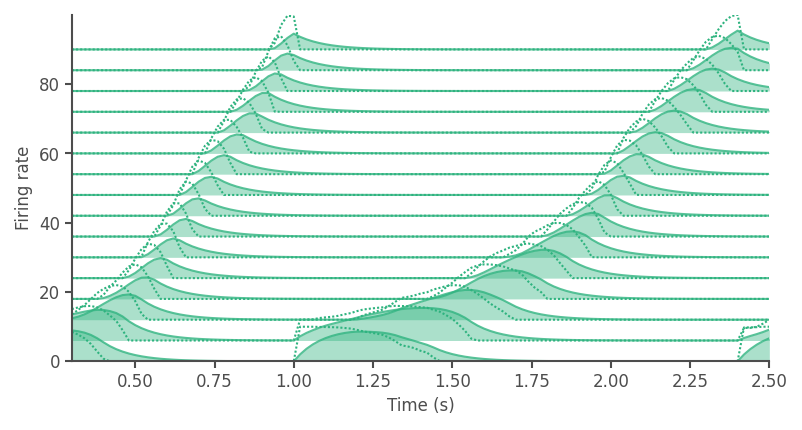

In [8]:
CA1s.plot_btsp_filtered("CA3_PCs", t_start=0.3, t_end=2.5);

## Multiple CA1 neurons

In [9]:
NUM_REWARDS = 16
MAX_NUM_STEPS = 5000
USE_HEBBIAN = True

CA1_params = {
    "n": 4,
    "init_weights_zero": True,
    "w_init_scale": 0.1, # set fairly small
    "btsp_tau": run_manager.AGENT_PARAMS["dt"] * 5,
    "btsp_fr": 50,
    "lr": 1e-4,
    "apply_Ojas_rule": True,
}

CA1_params_mult = copy.deepcopy(run_manager.CA1_PARAMS)
CA1_params_mult.update(CA1_params)

Agent dt        : 0.02
# CA3 PCs       : 16
# CA1s          : 4
CA1 init at 0   : True
CA1 init scale  : 0.1
CA1 BTSP tau    : 0.1
# rewards       : 16
Max # steps     : 5000
Hebbian learning: True
target # for BTSP: 5



 24%|█████████▏                            | 1206/5000 [00:02<00:09, 413.75it/s]


Trajectory lengths (17) to date: 1.42 +/- 0.46 sec each
Trajectory lengths (17) to date: 71.00 +/- 22.82 steps each


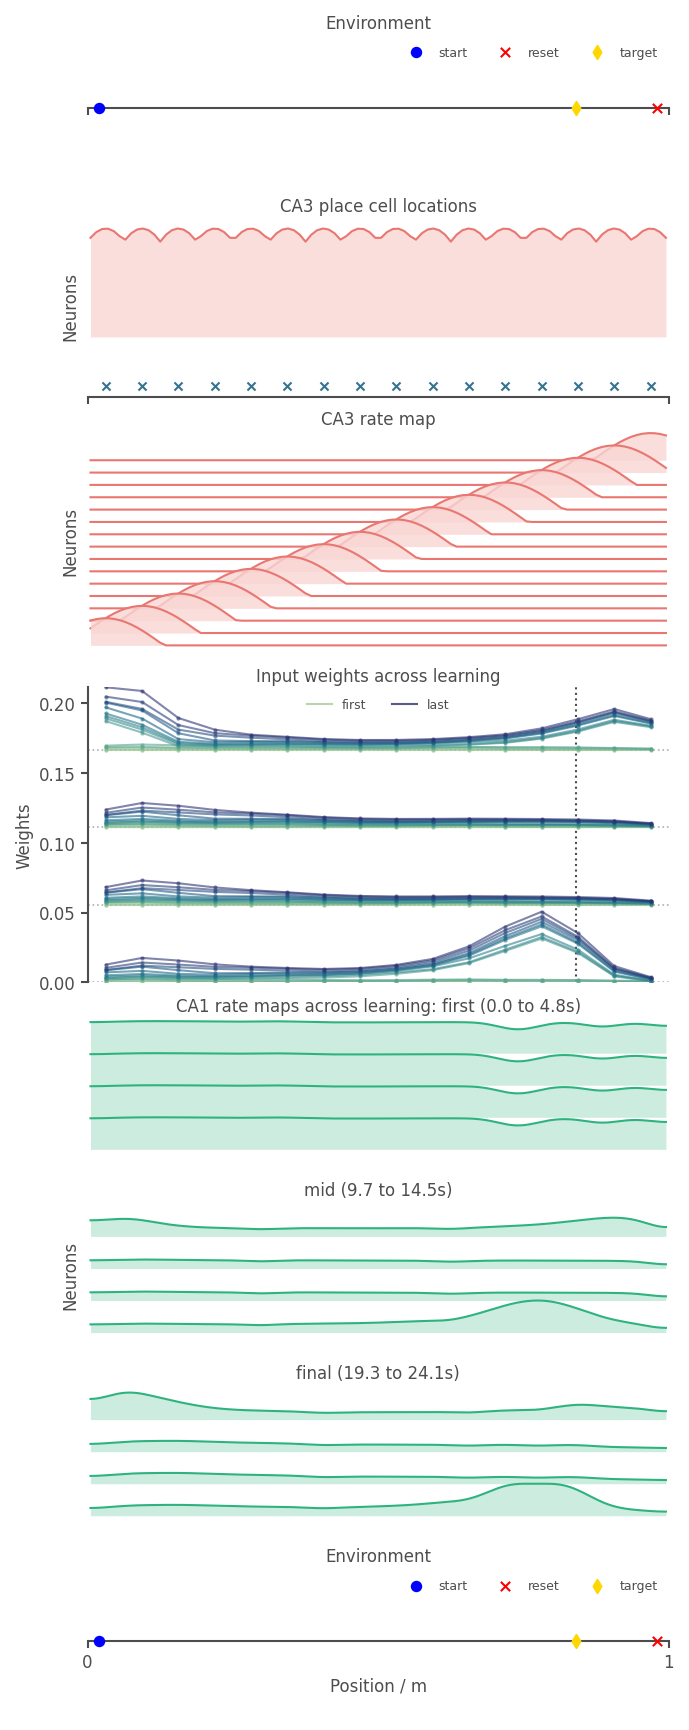

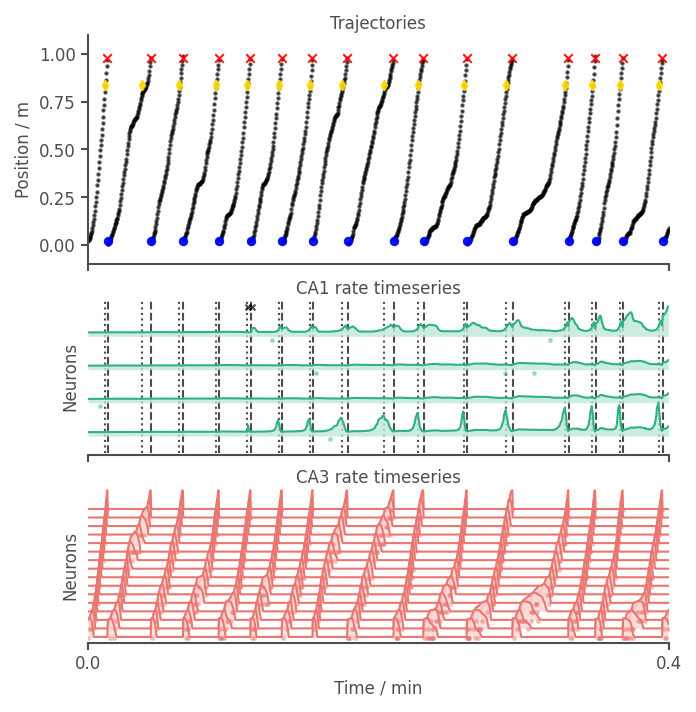

In [10]:
Env, Ag, CA3_PCs, CA1s = learn(
    run_manager.ENV_PARAMS, 
    run_manager.AGENT_PARAMS, 
    run_manager.CA3_PC_PARAMS, 
    CA1_params_mult,
    num_rewards=NUM_REWARDS, 
    max_num_steps=MAX_NUM_STEPS,
    use_Hebbian=USE_HEBBIAN,
    target_reach_num_for_btsp=5,
)

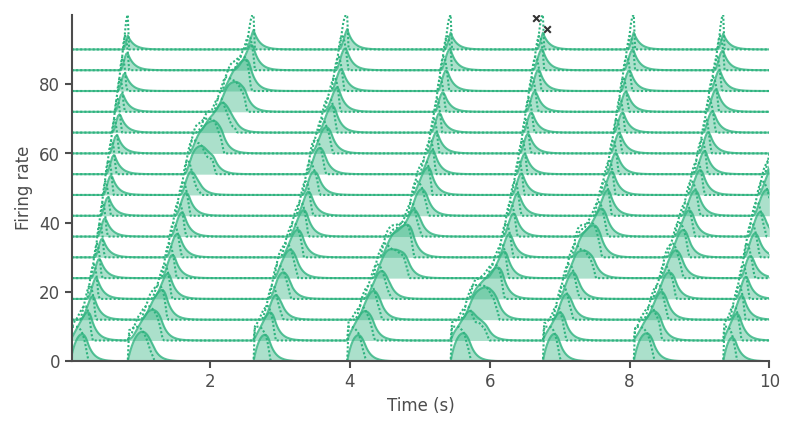

In [11]:
CA1s.plot_btsp_filtered("CA3_PCs", t_start=0, t_end=10);